# Comparaison γ constant vs γ adaptatif

**Modèle de Chiarella étendu** — Majewski, Ciliberti, Bouchaud (2020)

Ce notebook compare deux variantes du modèle sur 1 000 mois (≈ 83 ans) de simulation :

| Variante | Formulation |
|----------|-------------|
| **Baseline** | $\gamma(t) = \gamma_0$ (constante) |
| **Adaptatif** | $\gamma(t) = \gamma_0 \cdot \left(1 + \theta \cdot \dfrac{\sigma_{\text{réal}}(t)}{\sigma_{\text{baseline}}}\right)$ |

**Hypothèse testée** : un $\gamma$ croissant avec la volatilité (aversion au risque variable) réduit-il la formation de bulles extrêmes (mispricing $P_t - V_t$) ?

In [1]:
import sys
from pathlib import Path

# Assure que les modules src/ sont accessibles depuis notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from src.simulation import run_baseline, run_adaptive, merge_results, VOL_WINDOW_MONTHS
from src.analysis import (
    compute_returns,
    rolling_volatility,
    return_statistics,
    compare_models,
    full_report,
)

# Style global
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

SEED = 2024
print("Imports OK")

Imports OK


In [2]:
# ── Simulations ──────────────────────────────────────────────────────────────
print("Simulation baseline …")
res_base, df_base = run_baseline(seed=SEED)

print("Simulation adaptative (θ=1.0) …")
res_adap, df_adap = run_adaptive(theta=1.0, seed=SEED)

df = merge_results(df_base, df_adap)

# Rendements et mispricing
df["baseline_ret"]       = df["baseline_P"].diff()
df["adaptive_ret"]       = df["adaptive_P"].diff()
df["baseline_mispricing"] = df["baseline_P"] - df["baseline_V"]
df["adaptive_mispricing"] = df["adaptive_P"] - df["adaptive_V"]

# Volatilité réalisée glissante (12 mois) — même unité que les paramètres
r_base = df["baseline_ret"].dropna().to_numpy()
r_adap = df["adaptive_ret"].dropna().to_numpy()
vol_base = rolling_volatility(r_base, window=VOL_WINDOW_MONTHS)
vol_adap = rolling_volatility(r_adap, window=VOL_WINDOW_MONTHS)

print(f"DataFrame : {df.shape[0]} pas × {df.shape[1]} colonnes")
print(f"γ adaptatif — mean={res_adap.gamma.mean():.3f}  "
      f"min={res_adap.gamma.min():.3f}  max={res_adap.gamma.max():.3f}")

Simulation baseline …
Simulation adaptative (θ=1.0) …
DataFrame : 1001 pas × 13 colonnes
γ adaptatif — mean=3.810  min=2.000  max=4.877


---
## Figure 1 — Trajectoires de prix et valeur fondamentale

/var/folders/w7/0j__nhp56rzds_x7q38c8rsr0000gn/T/ipykernel_26103/2007858747.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


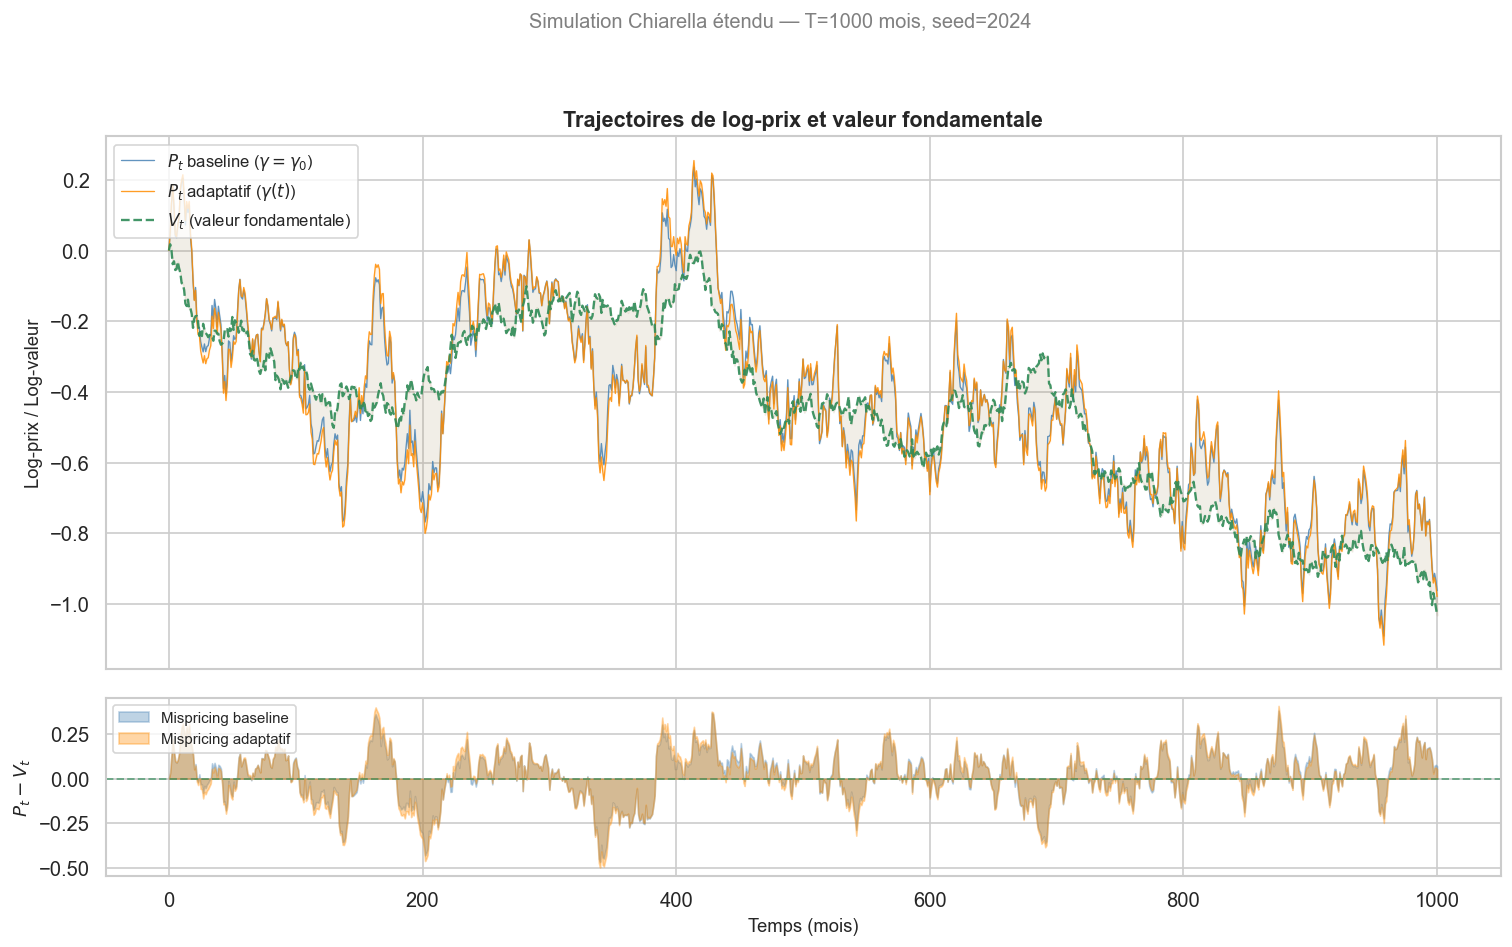

In [3]:
t = df["t"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})

# ── Panneau supérieur : trajectoires ─────────────────────────────────────────
ax = axes[0]
ax.plot(t, df["baseline_P"], lw=0.8, alpha=0.85, color="steelblue",
        label=r"$P_t$ baseline ($\gamma=\gamma_0$)")
ax.plot(t, df["adaptive_P"], lw=0.8, alpha=0.85, color="darkorange",
        label=r"$P_t$ adaptatif ($\gamma(t)$)")
ax.plot(t, df["baseline_V"], lw=1.4, ls="--", color="seagreen", alpha=0.9,
        label=r"$V_t$ (valeur fondamentale)")

ax.fill_between(t, df["baseline_P"], df["baseline_V"],
                alpha=0.07, color="steelblue")
ax.fill_between(t, df["adaptive_P"], df["adaptive_V"],
                alpha=0.07, color="darkorange")

ax.set_ylabel("Log-prix / Log-valeur")
ax.set_title("Trajectoires de log-prix et valeur fondamentale", fontweight="bold")
ax.legend(loc="upper left")

# ── Panneau inférieur : mispricing ────────────────────────────────────────────
ax2 = axes[1]
ax2.axhline(0, color="seagreen", lw=1.2, ls="--", alpha=0.6)
ax2.fill_between(t, df["baseline_mispricing"], 0,
                 alpha=0.35, color="steelblue", label="Mispricing baseline")
ax2.fill_between(t, df["adaptive_mispricing"], 0,
                 alpha=0.35, color="darkorange", label="Mispricing adaptatif")

ax2.set_xlabel("Temps (mois)")
ax2.set_ylabel(r"$P_t - V_t$")
ax2.legend(loc="upper left", fontsize=9)

plt.suptitle(
    f"Simulation Chiarella étendu — T={int(t[-1])} mois, seed={SEED}",
    y=1.01, fontsize=12, color="gray"
)
plt.tight_layout()
plt.savefig("fig1_trajectoires.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Figure 2 — Évolution de γ(t) et de la volatilité réalisée

On vérifie que la formule $\gamma(t) = \gamma_0 \cdot \bigl(1 + \theta \cdot \sigma_{\text{réal}}(t)/\sigma_{\text{baseline}}\bigr)$ réagit bien aux chocs de volatilité.

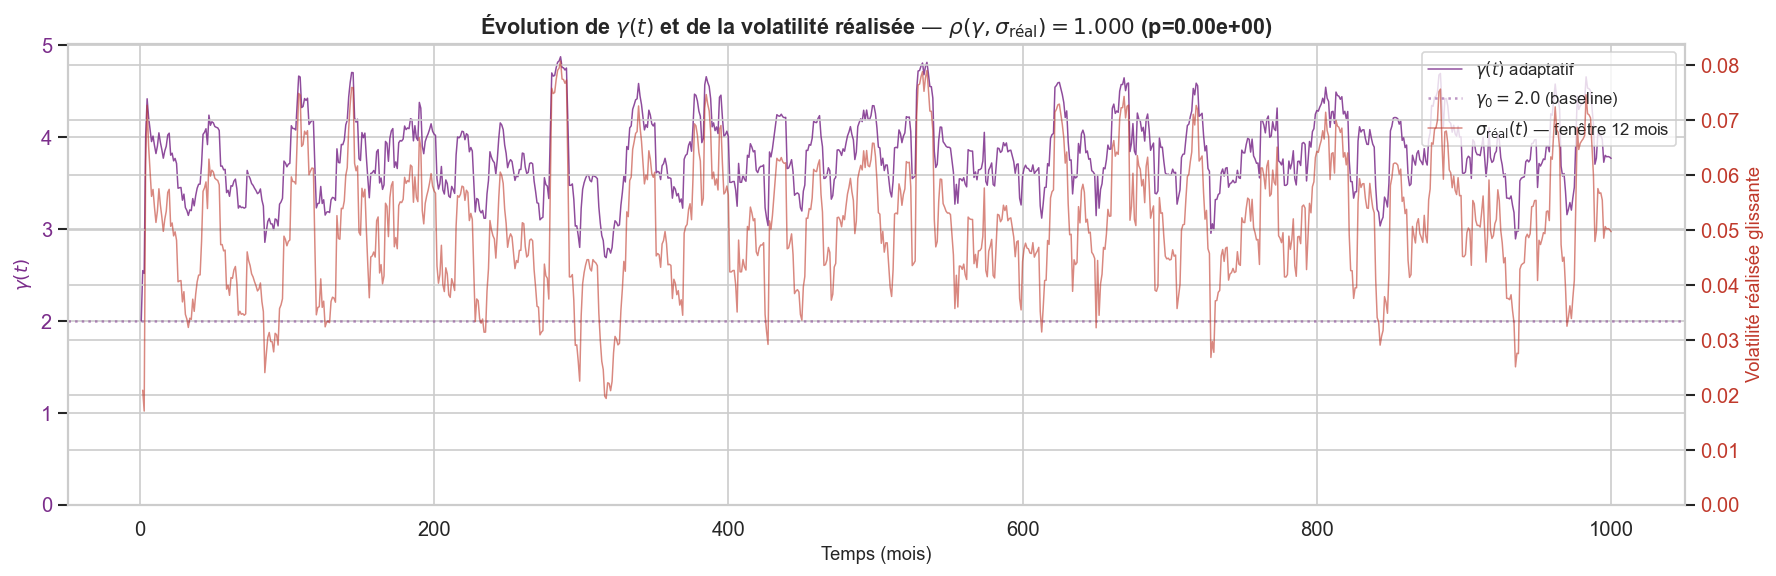

Corrélation Pearson γ(t) ↔ σ_réal : ρ = 0.9996  (p = 0.00e+00)


In [4]:
# ── Alignement temporel ────────────────────────────────────────────────────
# vol_adap a n_steps-1 points (après diff), gamma_adap a n_steps+1 points
t_ret   = t[1:]                          # t sans le premier point (après diff)
vol_adap_aligned = vol_adap              # shape (n_steps,) — identique à t_ret
gamma_adap       = df["adaptive_gamma"].to_numpy()[1:]  # aligne sur t_ret

fig, ax1 = plt.subplots(figsize=(15, 5))

# γ(t) — axe gauche
color_gamma = "#7B2D8B"   # violet
ax1.plot(t_ret, gamma_adap, lw=0.9, alpha=0.85,
         color=color_gamma, label=r"$\gamma(t)$ adaptatif")
ax1.axhline(2.0, color=color_gamma, ls=":", lw=1.5, alpha=0.5,
            label=r"$\gamma_0 = 2.0$ (baseline)")
ax1.set_xlabel("Temps (mois)")
ax1.set_ylabel(r"$\gamma(t)$", color=color_gamma)
ax1.tick_params(axis="y", labelcolor=color_gamma)
ax1.set_ylim(bottom=0)

# σ_réalisée — axe droit
ax2 = ax1.twinx()
color_vol = "#C0392B"   # rouge
ax2.plot(t_ret, vol_adap_aligned, lw=0.9, alpha=0.6,
         color=color_vol, label=r"$\sigma_{\text{réal}}(t)$ — fenêtre 12 mois")
ax2.set_ylabel(r"Volatilité réalisée glissante", color=color_vol)
ax2.tick_params(axis="y", labelcolor=color_vol)
ax2.set_ylim(bottom=0)

# Légendes combinées
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

# Corrélation Pearson entre γ(t) et σ_réal(t) (sans NaN)
mask = ~np.isnan(vol_adap_aligned)
rho, pval = stats.pearsonr(gamma_adap[mask], vol_adap_aligned[mask])
ax1.set_title(
    rf"Évolution de $\gamma(t)$ et de la volatilité réalisée — "
    rf"$\rho(\gamma, \sigma_{{\text{{réal}}}}) = {rho:.3f}$ (p={pval:.2e})",
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("fig2_gamma_vol.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Corrélation Pearson γ(t) ↔ σ_réal : ρ = {rho:.4f}  (p = {pval:.2e})")

---
## Figure 3 — Distribution du mispricing $P_t - V_t$

Un $\gamma$ adaptatif plus élevé pendant les phases de forte volatilité sature plus tôt la demande des trend-followers. L'hypothèse est que cela **réduit l'amplitude des bulles extrêmes** (queues de distribution du mispricing plus fines).

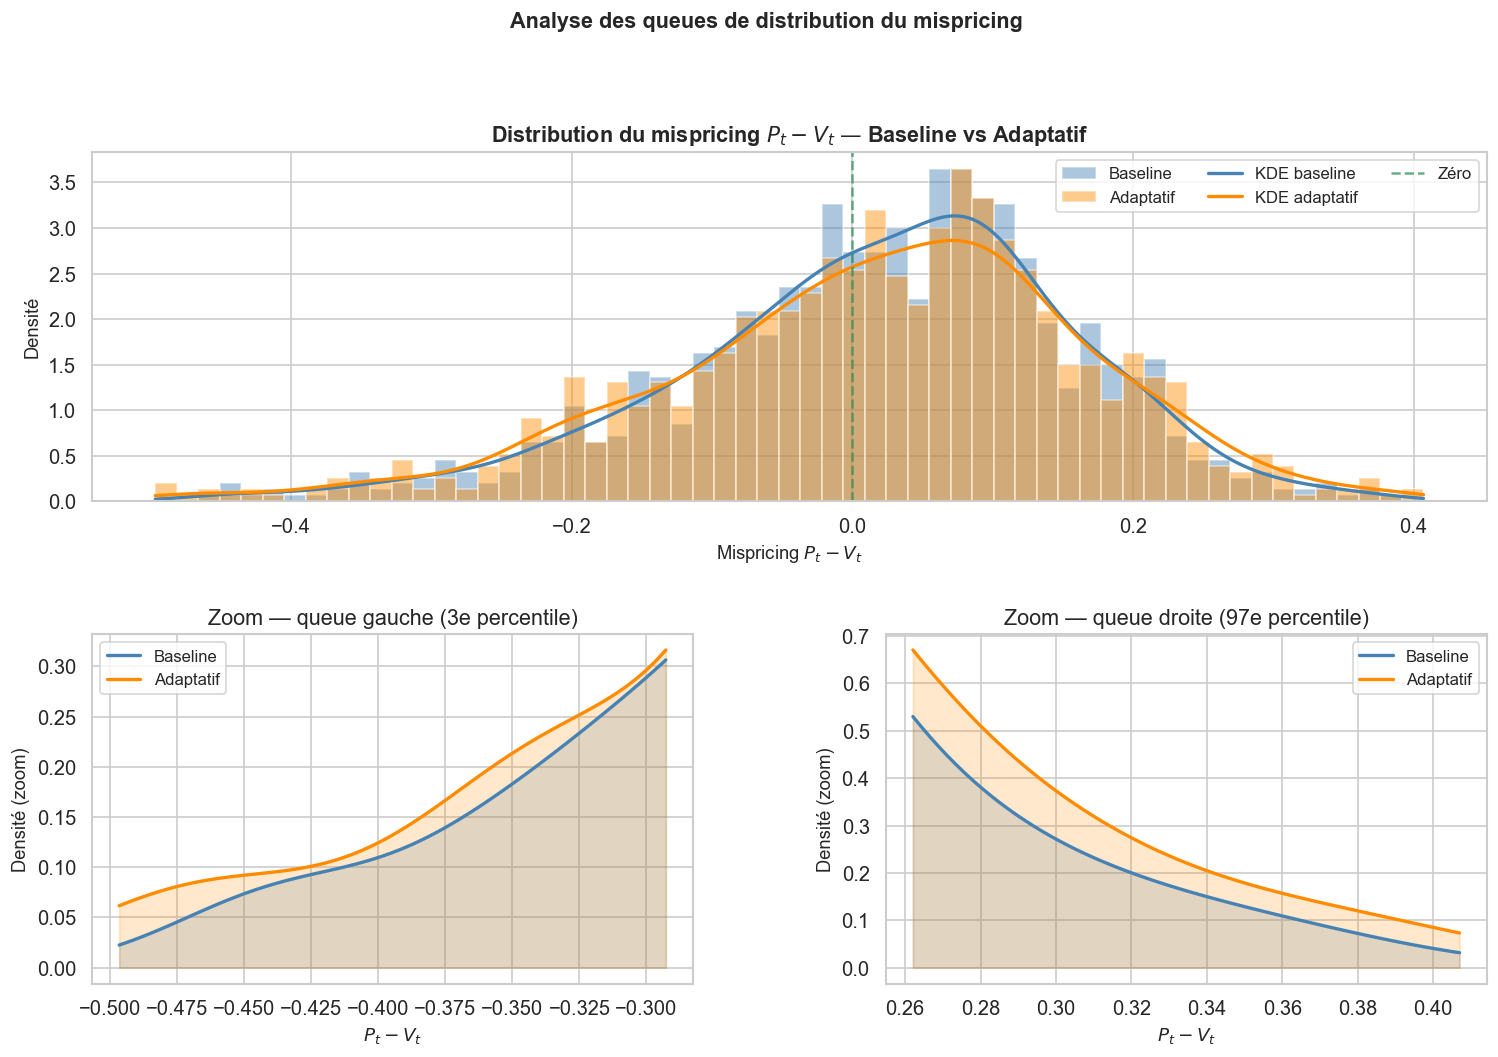

In [5]:
mp_base = df["baseline_mispricing"].dropna().to_numpy()
mp_adap = df["adaptive_mispricing"].dropna().to_numpy()

fig = plt.figure(figsize=(15, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ── (A) Histogrammes superposés ───────────────────────────────────────────────
ax_hist = fig.add_subplot(gs[0, :])

bins = np.linspace(
    min(mp_base.min(), mp_adap.min()),
    max(mp_base.max(), mp_adap.max()),
    60
)
ax_hist.hist(mp_base, bins=bins, density=True, alpha=0.45,
             color="steelblue", label="Baseline")
ax_hist.hist(mp_adap, bins=bins, density=True, alpha=0.45,
             color="darkorange", label="Adaptatif")

# KDE lissée
x_grid = np.linspace(bins[0], bins[-1], 400)
for mp, color, lbl in [
    (mp_base, "steelblue",  "KDE baseline"),
    (mp_adap, "darkorange", "KDE adaptatif"),
]:
    kde = stats.gaussian_kde(mp)
    ax_hist.plot(x_grid, kde(x_grid), lw=2, color=color, label=lbl)

ax_hist.axvline(0, color="seagreen", ls="--", lw=1.5, alpha=0.7, label="Zéro")
ax_hist.set_xlabel(r"Mispricing $P_t - V_t$")
ax_hist.set_ylabel("Densité")
ax_hist.set_title(r"Distribution du mispricing $P_t - V_t$ — Baseline vs Adaptatif",
                  fontweight="bold")
ax_hist.legend(ncol=3)

# ── (B) Queue gauche (zoom sur les bulles baissières) ────────────────────────
ax_left = fig.add_subplot(gs[1, 0])
q5 = np.percentile(np.concatenate([mp_base, mp_adap]), 3)
mask_left = x_grid < q5

kde_base = stats.gaussian_kde(mp_base)
kde_adap = stats.gaussian_kde(mp_adap)

ax_left.plot(x_grid[mask_left], kde_base(x_grid[mask_left]),
             lw=2, color="steelblue", label="Baseline")
ax_left.plot(x_grid[mask_left], kde_adap(x_grid[mask_left]),
             lw=2, color="darkorange", label="Adaptatif")
ax_left.fill_between(x_grid[mask_left], kde_base(x_grid[mask_left]), alpha=0.2, color="steelblue")
ax_left.fill_between(x_grid[mask_left], kde_adap(x_grid[mask_left]), alpha=0.2, color="darkorange")
ax_left.set_xlabel(r"$P_t - V_t$")
ax_left.set_ylabel("Densité (zoom)")
ax_left.set_title("Zoom — queue gauche (3e percentile)")
ax_left.legend()

# ── (C) Queue droite (zoom sur les bulles haussières) ───────────────────────
ax_right = fig.add_subplot(gs[1, 1])
q95 = np.percentile(np.concatenate([mp_base, mp_adap]), 97)
mask_right = x_grid > q95

ax_right.plot(x_grid[mask_right], kde_base(x_grid[mask_right]),
              lw=2, color="steelblue", label="Baseline")
ax_right.plot(x_grid[mask_right], kde_adap(x_grid[mask_right]),
              lw=2, color="darkorange", label="Adaptatif")
ax_right.fill_between(x_grid[mask_right], kde_base(x_grid[mask_right]), alpha=0.2, color="steelblue")
ax_right.fill_between(x_grid[mask_right], kde_adap(x_grid[mask_right]), alpha=0.2, color="darkorange")
ax_right.set_xlabel(r"$P_t - V_t$")
ax_right.set_ylabel("Densité (zoom)")
ax_right.set_title("Zoom — queue droite (97e percentile)")
ax_right.legend()

plt.suptitle("Analyse des queues de distribution du mispricing",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("fig3_mispricing.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Tableau récapitulatif des statistiques

In [6]:
# ── Statistiques des rendements ───────────────────────────────────────────────
report = full_report(df, annualization_factor=np.sqrt(12))

# Statistiques du mispricing
mp_stats = pd.DataFrame(
    {
        "baseline": {
            "mispricing_mean":    mp_base.mean(),
            "mispricing_std":     mp_base.std(ddof=1),
            "mispricing_skew":    stats.skew(mp_base),
            "mispricing_kurt":    stats.kurtosis(mp_base, fisher=True),
            "mispricing_q1pct":   np.percentile(mp_base, 1),
            "mispricing_q99pct":  np.percentile(mp_base, 99),
            "mispricing_max_abs": np.abs(mp_base).max(),
        },
        "adaptive": {
            "mispricing_mean":    mp_adap.mean(),
            "mispricing_std":     mp_adap.std(ddof=1),
            "mispricing_skew":    stats.skew(mp_adap),
            "mispricing_kurt":    stats.kurtosis(mp_adap, fisher=True),
            "mispricing_q1pct":   np.percentile(mp_adap, 1),
            "mispricing_q99pct":  np.percentile(mp_adap, 99),
            "mispricing_max_abs": np.abs(mp_adap).max(),
        },
    }
).T

full_stats = pd.concat([report, mp_stats], axis=1)
full_stats.index.name = "Modèle"

print("=== Statistiques complètes ===")
display(full_stats.round(4))

# Réduction relative du mispricing extrême
delta_std = (mp_adap.std(ddof=1) - mp_base.std(ddof=1)) / mp_base.std(ddof=1) * 100
delta_max = (np.abs(mp_adap).max() - np.abs(mp_base).max()) / np.abs(mp_base).max() * 100
print(f"\nVariation std(mispricing)    : {delta_std:+.2f} %")
print(f"Variation max|mispricing|    : {delta_max:+.2f} %")
print("(valeurs négatives = réduction des extrêmes par le γ adaptatif)")

=== Statistiques complètes ===


,mean,vol,skewness,kurt_excess,jarque_bera_pval,n_obs,gamma_mean,gamma_std,gamma_min,gamma_max,gamma_median,mispricing_mean,mispricing_std,mispricing_skew,mispricing_kurt,mispricing_q1pct,mispricing_q99pct,mispricing_max_abs
Modèle,,,,,,,,,,,,,,,,,,
baseline,-0.0033,0.1805,0.0435,0.0738,0.7625,1000.0,2.0000,0.0000,2.0,2.0000,2.0000,0.0191,0.1387,-0.5178,0.4710,-0.3614,0.3023,0.4656
adaptive,-0.0034,0.1808,0.0483,0.0664,0.7511,1000.0,3.8098,0.4155,2.0,4.8774,3.8033,0.0171,0.1497,-0.4668,0.4179,-0.3848,0.3383,0.4966



Variation std(mispricing)    : +7.90 %
Variation max|mispricing|    : +6.65 %
(valeurs négatives = réduction des extrêmes par le γ adaptatif)
